# Imports

In [90]:
%matplotlib inline

import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from scipy.interpolate import CubicSpline

In [91]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

# Datos

In [92]:
df = pd.read_excel("datafile.xlsx")

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4704 entries, 0 to 4703
Data columns (total 32 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Iteration  4704 non-null   int64  
 1   ginert     4704 non-null   int64  
 2   alb        4704 non-null   float64
 3   taud       4704 non-null   float64
 4   tinit      4704 non-null   int64  
 5   als        4704 non-null   int64  
 6   deltaT     4704 non-null   float64
 7   0          4704 non-null   float64
 8   1          4704 non-null   float64
 9   2          4704 non-null   float64
 10  3          4704 non-null   float64
 11  4          4704 non-null   float64
 12  5          4704 non-null   float64
 13  6          4704 non-null   float64
 14  7          4704 non-null   float64
 15  8          4704 non-null   float64
 16  9          4704 non-null   float64
 17  10         4704 non-null   float64
 18  11         4704 non-null   float64
 19  12         4704 non-null   float64
 20  13      

In [94]:
df.head()

,Iteration,ginert,alb,taud,tinit,als,deltaT,0,1,2,...,15,16,17,18,19,20,21,22,23,24
0,1,100,0.05,0.2,215,0,0.265000,179.853271,177.582657,175.545532,...,296.103210,281.968475,261.118500,231.862885,204.973282,195.599808,190.029358,185.977463,182.766388,180.118271
1,2,100,0.05,0.2,215,15,0.229401,177.614517,175.593079,173.792130,...,288.832458,273.791992,251.982315,221.672287,200.039429,192.013214,186.956131,183.195267,180.182556,177.843918
2,3,100,0.05,0.2,215,30,0.182938,175.495163,173.666901,172.143188,...,280.964355,264.990173,242.143173,211.378998,195.387222,188.460190,183.871841,180.551224,177.882278,175.678101
3,4,100,0.05,0.2,215,45,0.171067,173.993774,172.335205,170.909851,...,273.449493,256.646423,232.795624,203.242004,191.432007,185.406815,181.362061,178.391342,176.069458,174.164841
4,5,100,0.05,0.2,215,60,0.232117,172.922607,171.527740,170.349625,...,267.279877,249.793732,225.099960,198.392685,188.619308,183.306030,179.690979,176.967621,174.822739,173.154724


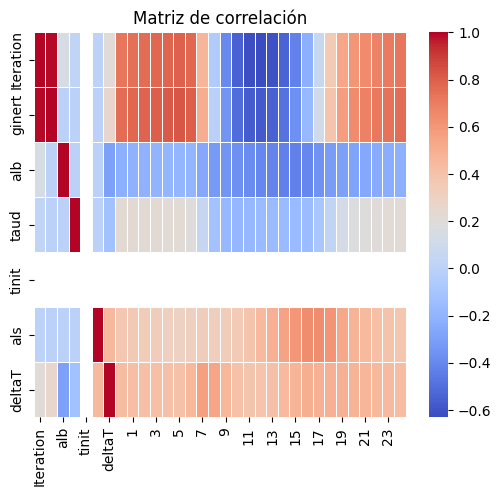

In [95]:
df_numerico = df.select_dtypes(include=['number'])
correlacion = df_numerico.corr()

plt.figure(figsize=(6,5))
sns.heatmap(correlacion[:7], annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de correlación')
plt.show()

<Axes: >

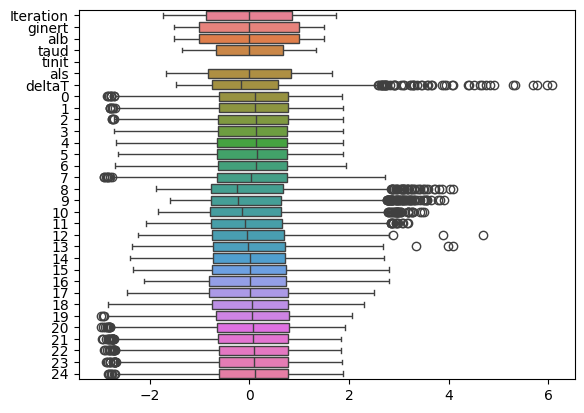

In [96]:
df_escalado = (df - df.mean()) / df.std()

sns.boxplot(data=df_escalado, orient="h")



---



# Máximos y mínimos

In [97]:
horas = np.arange(25)
h = np.linspace(0, 24, 2000)

t_max, t_min, h_max, h_min = [], [], [], []

for _, fila in df.iterrows():
    curva = CubicSpline(horas, fila[7:].values.astype(float))(h)
    t_max.append(np.max(curva))
    t_min.append(np.min(curva))
    h_max.append(h[np.argmax(curva)])
    h_min.append(h[np.argmin(curva)])

df["T_max"] = t_max
df["h_max"] = h_max
df["T_min"] = t_min
df["h_min"] = h_min



In [98]:
df["h_min"].head()

,h_min
0,6.459230
1,6.207104
2,5.810905
3,5.702851
4,5.678839




---



# Modelo

In [99]:

col_temps = df.columns[7:32]

# X = df[list(col_temps)]
X = df[list(col_temps) + ["taud", "tinit", "als"]]

X.columns = X.columns.astype(str)

y = df[["alb", "ginert"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [100]:

modelo=XGBRegressor(n_estimators=1000, learning_rate=0.01)
modelo.fit(X_train, y_train)
y_model = modelo.predict(X_test)

print("Resultado: ")
results = {}
results['mdl'] = r2_score(y_test, y_model)
results['mdl']

Resultado: 


0.9870261549949646

Sobreaprendizaje?

In [101]:
y_train_pred = modelo.predict(X_train)
y_test_pred = modelo.predict(X_test)

print("R² train:", r2_score(y_train, y_train_pred))
print("R² test: ", r2_score(y_test, y_test_pred))

R² train: 0.99741530418396
R² test:  0.9870261549949646


In [102]:
print("R² alb:   ", r2_score(y_test["alb"],    y_model[:, 0]))
print("R² ginert:", r2_score(y_test["ginert"],  y_model[:, 1]))

R² alb:    0.9787765405141841
R² ginert: 0.9952757954597473


No hay sobreaprendizaje -> OK

In [103]:
import joblib

joblib.dump(modelo, "modelo.pkl")

['modelo.pkl']

# Pruebas

In [104]:

modelo = joblib.load("modelo.pkl")

# Datos
temperaturas = [212.17,210.54,209.04,207.65 ,206.35, 205.13, 205.81, 212.94, 225.81, 240.81, 254.59,264.92, 270.63,271.32, 267.11, 258.61,247.12,235.92,228.68, 224.28, 221.00, 218.34, 216.07, 214.08, 212.29]
parametros   = [1.4, 218, 180]  # taud, tinit, als



entrada = np.array([temperaturas + parametros])

prediccion = modelo.predict(entrada)
print("alb:   ", prediccion[0][0])
print("ginert:", prediccion[0][1])

alb:    0.22631095
ginert: 424.51978
